In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

from common import EVALUATE_ALL_CSVS

model = "EGFR_MAPK__logobs"
data = "dream_cytof"
filename = "evaluate_all_figure1a"

df = pd.read_csv(EVALUATE_ALL_CSVS.format(model=model, data=data, filename=filename), index_col=0)
df.model.fillna(model, inplace=True)  # single model investigated in this batch of runs

In [2]:
train_df = df[df.dataset == "train"]
train_df.features.fillna("None", inplace=True)

val_df = df[df.dataset == "val"]
val_df.features.fillna("None", inplace=True)

In [3]:
import re
import numpy as np

# 1) filter and copy to avoid SettingWithCopyWarning
baselines_df = df.loc[df['ref'] != 'DMM'].copy()

# 2) build 'group' as ref+context
baselines_df['group'] = baselines_df['ref'].astype(str) + baselines_df['context'].astype(str)

# 3) collapse 'avg_model{context}' -> 'avg_model' and 'sample{context}' -> 'sample'
contexts = ['cytof_init', 'proteomics', 'transcriptomics', 'multimodal']
pat = '|'.join(map(re.escape, contexts))
baselines_df['group'] = (
    baselines_df['group']
    .str.replace(rf'^(avg_model)({pat})$', r'\1', regex=True)
    .str.replace(rf'^(sample)({pat})$', r'\1', regex=True)
)

# 4) if ref is 'avg_model' or 'sample', set context to None (use np.nan if you prefer missing)
baselines_df.loc[baselines_df['ref'].isin(['avg_model']), 'context'] = 'avg_model'
baselines_df.loc[baselines_df['ref'].isin(['sample']), 'context'] = 'sample'

# 5) drop duplicates
baselines_df = baselines_df.drop_duplicates()

In [4]:
baselines_df

,dataset,ref,model,samples,context,features,n_hidden,depth,l1reg_inflater_output,l2reg_inflater_output,recon_loss,inflater_output_reg_epoch,job,n_epoch,inflater_bound,rmse,group
29,train,avg_model,EGFR_MAPK__logobs,HCC1500,avg_model,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.604656,avg_model
31,train,avg_model,EGFR_MAPK__logobs,MCF7,avg_model,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.608942,avg_model
33,train,avg_model,EGFR_MAPK__logobs,UACC3199,avg_model,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.608707,avg_model
148,val,avg_model,EGFR_MAPK__logobs,UACC3199,avg_model,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.900677,avg_model
146,val,avg_model,EGFR_MAPK__logobs,MCF7,avg_model,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.884996,avg_model
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,train,sample,EGFR_MAPK__logobs,HCC1500,sample,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.258488,sample
223,val,sample,EGFR_MAPK__logobs,EVSAT,sample,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.242057,sample
221,val,sample,EGFR_MAPK__logobs,BT20,sample,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.301176,sample
7,train,sample,EGFR_MAPK__logobs,MCF7,sample,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.258839,sample


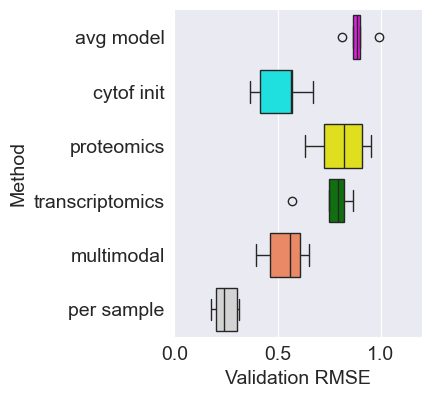

In [13]:
g = sns.FacetGrid(
    baselines_df[
        (baselines_df.ref.isin(["avg_model", "sample", "elasticnet"]))
        &
        (baselines_df.dataset == "val")
         ],
    height=4,
    aspect=1,
)

g.map_dataframe(
    sns.boxplot,
    y="context",
    x="rmse",
    order=["avg_model", "cytof_init", "proteomics", "transcriptomics", "multimodal", "sample"],
    hue="group",
    palette={
        "avg_model": "fuchsia",
        "sample": "lightgray",
        "elasticnetcytof_init": "cyan",
        "elasticnetproteomics": "yellow",
        "elasticnettranscriptomics": "green",
        "elasticnetmultimodal": "coral",
    },
    hue_order=["avg_model", "elasticnetcytof_init", "elasticnetproteomics", "elasticnettranscriptomics", "elasticnetmultimodal", "sample"],
)

plt.yticks(
    plt.gca().get_yticks(),
    labels=["avg model", "cytof init", "proteomics", "transcriptomics", "multimodal", "per sample"],
    fontsize=14
)

plt.xticks(
    plt.gca().get_xticks(),
    fontsize=14
)

# Axis labels
g.set_axis_labels("Validation RMSE", "Method", fontsize=14)

# Remove the "context = " prefix from column titles
g.set_titles(col_template="{col_name}")

plt.xlim([0, 1.2])
plt.xticks([0, 0.50, 1.00])
plt.savefig("base_fig1a_baselines.svg")